In [5]:
import pandas as pd 

In [6]:
data = pd.read_csv("spam.csv", encoding = "latin-1")

In [ ]:
# Listing the first five rows of the dataset
print(data.head)

In [ ]:
#Exploring the dataset

data.info()

In [6]:
#Exploring the dataset

data.shape

(5572, 5)

In [8]:
# Renaming the column from v1 and v2 to label and text

data = data.rename(columns={'v1':'label','v2':'text'})

In [ ]:
# Check for classfication, showing class imbalance

data['label'].value_counts()

In [ ]:
# checkign for missing values

data.isnull().sum()

In [ ]:
#Looking at random messages

print(data.sample(5))

In [10]:
# Converting labels to numbers, neural networks require numbers not text labels
data['label'] = data['label'].map({'ham':0,'spam':1})

In [11]:
# Convert Text Into Numbers
#Neural networks cannot read text directly.
#We convert text using TF-IDF vectorization.
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['text']).toarray()
y = data['label']

In [12]:
# Split Data into Training and Testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [13]:
# Building the Simple Neural Network
# Using TensorFlow/Keras

from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)



In [ ]:
# Training the model
model.fit(
    X_train,
    y_train,
    epochs = 10,
    batch_size = 32
)

In [ ]:
# Evaluate the Model

loss, accuracy = model.evaluate(X_test,y_test)

print("Accuracy:", accuracy)
print("Loss:",loss)

In [ ]:
# Test With New Messages
new_messages = [
"Congratulations you won a free prize",
    "Are we meeting tomorrow?",
    "what is your phone number"
]

new_x = vectorizer.transform(new_messages).toarray()

predictions = model.predict(new_x)

print(predictions)

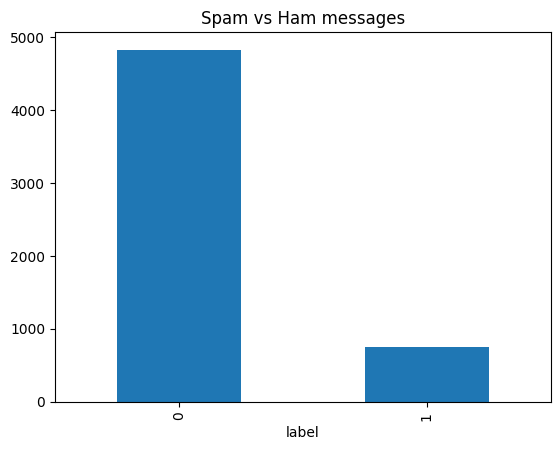

In [26]:
# Visualize Class Distribution

import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham messages")

plt.show()